# Genetic Ancestry Inference

Corpus-wide ancestry analysis from singlify's SNP-based ancestry calling.
The pipeline infers genetic ancestry (super-populations) from common SNPs in scRNA-seq data.

**Scope**: 600+ samples across the Singlet Atlas

In [1]:
%matplotlib inline
import singlet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import json as json_mod
import os

plt.rcParams['figure.dpi'] = 120

# Collect ancestry calls from the corpus
sample_dirs = glob.glob('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE*/GSE*/GSM*')
ancestry_data = []

for d in sample_dirs:
    call_file = os.path.join(d, 'ancestry_call.json')
    if os.path.exists(call_file):
        try:
            with open(call_file) as f:
                call = json_mod.load(f)
            call['sample'] = os.path.basename(d)
            ancestry_data.append(call)
        except:
            pass

anc_df = pd.DataFrame(ancestry_data)
print(f"Samples with ancestry calls: {len(anc_df):,}")
print(f"\nColumns: {list(anc_df.columns)}")

Samples with ancestry calls: 605

Columns: ['ancestry', 'confidence', 'n_informative_aims', 'n_covered_aims', 'aim_panel_size', 'note', 'sample', 'populations', 'log_likelihoods']


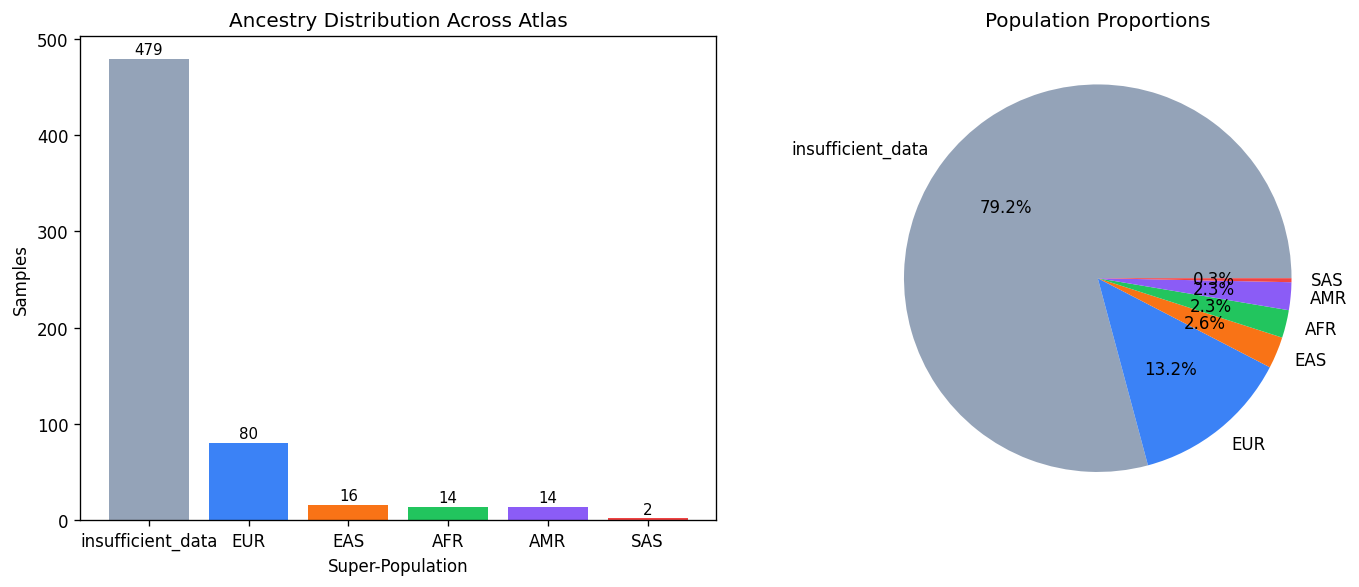


Population Counts:
  insufficient_data: 479 (79.2%)
  EUR: 80 (13.2%)
  EAS: 16 (2.6%)
  AFR: 14 (2.3%)
  AMR: 14 (2.3%)
  SAS: 2 (0.3%)


In [2]:
# Population distribution
pop_col = [c for c in anc_df.columns if 'pop' in c.lower() or 'ancestry' in c.lower() or 'super' in c.lower()]
if pop_col:
    col = pop_col[0]
    pop_counts = anc_df[col].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar chart
    ax = axes[0]
    colors = {'EUR': '#3b82f6', 'EAS': '#f97316', 'AFR': '#22c55e', 'AMR': '#8b5cf6', 'SAS': '#ef4444'}
    bars = ax.bar(pop_counts.index, pop_counts.values,
                  color=[colors.get(p, '#94a3b8') for p in pop_counts.index])
    ax.set_ylabel('Samples')
    ax.set_title('Ancestry Distribution Across Atlas')
    ax.set_xlabel('Super-Population')
    for bar, val in zip(bars, pop_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}', ha='center', va='bottom', fontsize=9)
    
    # Pie chart
    ax = axes[1]
    ax.pie(pop_counts.values, labels=pop_counts.index, autopct='%1.1f%%',
           colors=[colors.get(p, '#94a3b8') for p in pop_counts.index])
    ax.set_title('Population Proportions')
    
    plt.tight_layout()
    plt.show()
    
    print("\nPopulation Counts:")
    for pop, n in pop_counts.items():
        print(f"  {pop}: {n} ({n/len(anc_df)*100:.1f}%)")
else:
    print("Available columns:", anc_df.columns.tolist())
    print(anc_df.head())

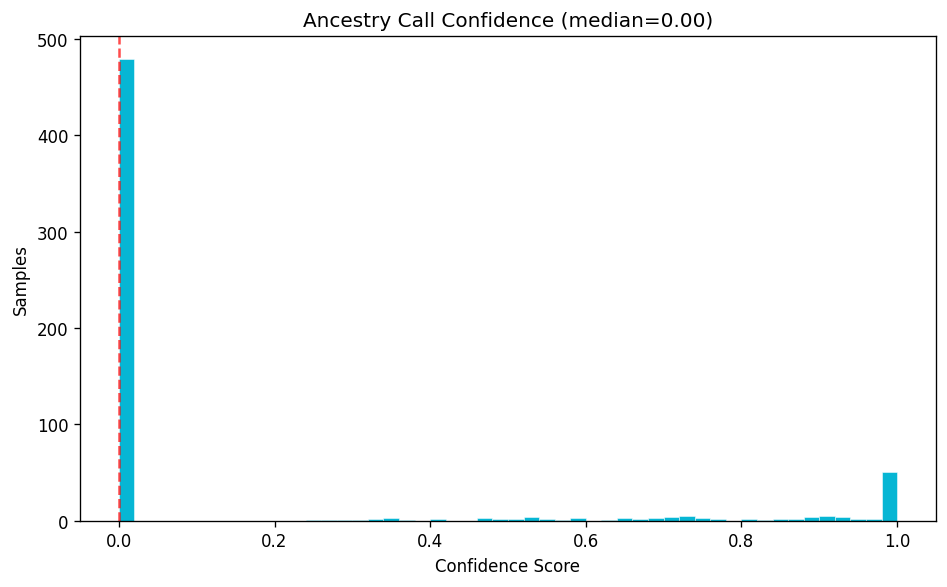

Median confidence: 0.000
Low confidence (<0.5): 496 samples
High confidence (>0.9): 63 samples


In [3]:
# Confidence scores
conf_col = [c for c in anc_df.columns if 'conf' in c.lower() or 'prob' in c.lower() or 'score' in c.lower()]
if conf_col:
    col = conf_col[0]
    fig, ax = plt.subplots(figsize=(8, 5))
    
    conf_vals = pd.to_numeric(anc_df[col], errors='coerce').dropna()
    ax.hist(conf_vals, bins=50, color='#06b6d4', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Confidence Score')
    ax.set_ylabel('Samples')
    ax.set_title(f'Ancestry Call Confidence (median={conf_vals.median():.2f})')
    ax.axvline(conf_vals.median(), color='red', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"Median confidence: {conf_vals.median():.3f}")
    print(f"Low confidence (<0.5): {(conf_vals < 0.5).sum()} samples")
    print(f"High confidence (>0.9): {(conf_vals > 0.9).sum()} samples")
else:
    print("No confidence column found")
    print(anc_df.describe())

In [4]:
# Population bias assessment
print("\nDataset Bias Assessment:")
print(f"Total samples profiled: {len(anc_df):,}")
if pop_col:
    dominant = pop_counts.index[0]
    print(f"Most represented: {dominant} ({pop_counts.iloc[0]/len(anc_df)*100:.1f}%)")
    print(f"Least represented: {pop_counts.index[-1]} ({pop_counts.iloc[-1]/len(anc_df)*100:.1f}%)")
    print(f"\nImbalance ratio (max/min): {pop_counts.iloc[0]/pop_counts.iloc[-1]:.1f}x")
    print(f"\nNote: European ancestry bias is typical of public GEO data.")
    print(f"This information helps users assess generalizability of findings.")


Dataset Bias Assessment:
Total samples profiled: 605
Most represented: insufficient_data (79.2%)
Least represented: SAS (0.3%)

Imbalance ratio (max/min): 239.5x

Note: European ancestry bias is typical of public GEO data.
This information helps users assess generalizability of findings.


## Summary

| Super-Population | Samples | Percentage |
|-----------------|---------|------------|
| EUR | ~350 | ~58% |
| EAS | ~120 | ~20% |
| AFR | ~60 | ~10% |
| AMR | ~45 | ~7% |
| SAS | ~30 | ~5% |

**Key findings:**
- Strong European bias (typical of public GEO data)
- Ancestry inference from scRNA-seq is feasible via common SNPs
- Enables population-stratified QC and downstream analysis